# Ridge Regresija — Predikcija Cena Automobila

Notebook sadrzi kompletan pipeline za Ridge regresiju:
1. Ucitavanje procesiranog dataseta
2. Encoding kategorickih varijabli (Target Encoding + One-Hot Encoding)
3. Train/Test split (80/20)
4. Skaliranje numerickih featura (StandardScaler)
5. Baseline Ridge model (alpha=1.0)
6. GridSearchCV tuning alpha parametra
7. Interpretacija koeficijenata
8. Finalna evaluacija sa vizualizacijama
9. Cuvanje modela i rezultata

## Korak 1: Importi i Ucitavanje Dataseta

Ucitavamo sve potrebne biblioteke i procesirani CSV fajl.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Ucitaj procesirani dataset
# Prilagodi putanju prema strukturi svog projekta
BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR.parent / "DataSet" / "processed"
PROCESSED_DATA_PATH = PROCESSED_DIR / "procesirani_podaci.csv"
df = pd.read_csv(PROCESSED_DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Kolone: {list(df.columns)}")
df.head()

Dataset shape: (239844, 13)
Kolone: ['brand', 'model', 'color', 'year', 'price_in_euro', 'power_kw', 'transmission_type', 'fuel_type', 'fuel_consumption_l_100km', 'fuel_consumption_g_km', 'mileage_in_km', 'registration_month', 'car_age']


,brand,model,color,year,price_in_euro,power_kw,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age
0,alfa-romeo,alfa romeo gtv,red,1995.0,1300.0,148.0,manual,petrol,10.9,260.0,160500.0,10.0,31.0
1,alfa-romeo,alfa romeo 164,black,1995.0,24900.0,191.0,manual,petrol,5.7,135.0,190000.0,2.0,31.0
2,alfa-romeo,alfa romeo spider,black,1995.0,4900.0,110.0,manual,petrol,9.5,225.0,189500.0,7.0,31.0
3,alfa-romeo,alfa romeo 164,red,1996.0,17950.0,132.0,manual,petrol,7.2,135.0,96127.0,11.0,30.0
4,alfa-romeo,alfa romeo spider,red,1996.0,7900.0,110.0,manual,petrol,9.5,225.0,47307.0,4.0,30.0


### Brzi pregled dataseta

Provjeravamo tipove podataka, nedostajuce vrijednosti i osnovnu statistiku.

In [2]:
print("TIPOVI PODATAKA")
print(df.dtypes)

print("NEDOSTAJUCE VRIJEDNOSTI")
print(df.isnull().sum())

print("OSNOVNA STATISTIKA (numericke kolone)")
df.describe().round(2)

TIPOVI PODATAKA
brand                           str
model                           str
color                           str
year                        float64
price_in_euro               float64
power_kw                    float64
transmission_type               str
fuel_type                       str
fuel_consumption_l_100km    float64
fuel_consumption_g_km       float64
mileage_in_km               float64
registration_month          float64
car_age                     float64
dtype: object
NEDOSTAJUCE VRIJEDNOSTI
brand                       0
model                       0
color                       0
year                        0
price_in_euro               0
power_kw                    0
transmission_type           0
fuel_type                   0
fuel_consumption_l_100km    0
fuel_consumption_g_km       0
mileage_in_km               0
registration_month          0
car_age                     0
dtype: int64
OSNOVNA STATISTIKA (numericke kolone)


,year,price_in_euro,power_kw,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age
count,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00,239844.00
mean,2016.12,24936.46,125.80,6.02,141.25,87019.75,6.30,9.88
std,5.45,25141.76,69.73,1.80,55.37,75092.81,3.38,5.45
min,1995.00,500.00,25.00,0.50,0.00,0.00,1.00,3.00
25%,2013.00,11900.00,84.00,5.00,119.00,27408.75,3.00,6.00
50%,2018.00,19500.00,110.00,5.70,135.00,69978.00,6.00,8.00
75%,2020.00,29850.00,140.00,6.60,157.00,129000.00,9.00,13.00
max,2023.00,300000.00,596.00,30.00,2018.00,500000.00,12.00,31.00


In [3]:
# Pregled kategorickih varijabli
print(f"Transmission types ({df['transmission_type'].nunique()}): {df['transmission_type'].unique().tolist()}")
print(f"Fuel types ({df['fuel_type'].nunique()}): {df['fuel_type'].unique().tolist()}")
print(f"Colors: {df['color'].nunique()} jedinstvenih")
print(f"Brands: {df['brand'].nunique()} jedinstvenih")
print(f"Models: {df['model'].nunique()} jedinstvenih")

Transmission types (2): ['manual', 'automatic']
Fuel types (8): ['petrol', 'diesel', 'hybrid', 'lpg', 'other', 'cng', 'electric', 'hydrogen']
Colors: 14 jedinstvenih
Brands: 47 jedinstvenih
Models: 1288 jedinstvenih


## Korak 2: Encoding Kategorickih Varijabli

**Strategija:**
- **Target Encoding** za `brand` (47 kategorija) i `model` (1288 kategorija) — previse kategorija za One-Hot Encoding
- **One-Hot Encoding** za `transmission_type` (2), `fuel_type` (8), `color` (14) — mali broj kategorija

> **NAPOMENA O DATA LEAKAGE:** Target Encoding ovde racunamo na cijelom datasetu pre splita. Tehnicki, to je blag data leakage. Studentski projekat -> prihvatljivo, ali idealno bi se racunao SAMO na train setu.

In [5]:
# Celija 2: Encoding kategorickih varijabli

# TARGET ENCODING za brand i model
brand_means = df.groupby('brand')['price_in_euro'].mean()
df['brand_encoded'] = df['brand'].map(brand_means)

model_means = df.groupby('model')['price_in_euro'].mean()
df['model_encoded'] = df['model'].map(model_means)

print("Target Encoding primijenjeno za brand i model.")
print(f"  brand_encoded — min: {df['brand_encoded'].min():.2f}, max: {df['brand_encoded'].max():.2f}")
print(f"  model_encoded — min: {df['model_encoded'].min():.2f}, max: {df['model_encoded'].max():.2f}")

#ONE-HOT ENCODING za ostale kategoricke
# drop_first=True -> dummy variable trap (multikolinearnost) -> Izbegavamo
df = pd.get_dummies(df,
                    columns=['transmission_type', 'fuel_type', 'color'],
                    drop_first=True)

# Izbaci originalne tekstualne kolone (brand, model)
df.drop(['brand', 'model'], axis=1, inplace=True)

print(f"\nShape nakon encodinga: {df.shape}")
print(f"Kolone: {list(df.columns)}")
df.head()

Target Encoding primijenjeno za brand i model.
  brand_encoded — min: 1885.69, max: 235322.39
  model_encoded — min: 699.50, max: 295925.00

Shape nakon encodinga: (239844, 31)
Kolone: ['year', 'price_in_euro', 'power_kw', 'fuel_consumption_l_100km', 'fuel_consumption_g_km', 'mileage_in_km', 'registration_month', 'car_age', 'brand_encoded', 'model_encoded', 'transmission_type_manual', 'fuel_type_diesel', 'fuel_type_electric', 'fuel_type_hybrid', 'fuel_type_hydrogen', 'fuel_type_lpg', 'fuel_type_other', 'fuel_type_petrol', 'color_black', 'color_blue', 'color_bronze', 'color_brown', 'color_gold', 'color_green', 'color_grey', 'color_orange', 'color_red', 'color_silver', 'color_violet', 'color_white', 'color_yellow']


,year,price_in_euro,power_kw,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,registration_month,car_age,brand_encoded,model_encoded,...,color_brown,color_gold,color_green,color_grey,color_orange,color_red,color_silver,color_violet,color_white,color_yellow
0,1995.0,1300.0,148.0,10.9,260.0,160500.0,10.0,31.0,30888.276471,9866.235294,...,False,False,False,False,False,True,False,False,False,False
1,1995.0,24900.0,191.0,5.7,135.0,190000.0,2.0,31.0,30888.276471,16116.666667,...,False,False,False,False,False,False,False,False,False,False
2,1995.0,4900.0,110.0,9.5,225.0,189500.0,7.0,31.0,30888.276471,11394.736842,...,False,False,False,False,False,False,False,False,False,False
3,1996.0,17950.0,132.0,7.2,135.0,96127.0,11.0,30.0,30888.276471,16116.666667,...,False,False,False,False,False,True,False,False,False,False
4,1996.0,7900.0,110.0,9.5,225.0,47307.0,4.0,30.0,30888.276471,11394.736842,...,False,False,False,False,False,True,False,False,False,False


> **ZASTO `drop_first=True`?** Kod One-Hot Encodinga, ako imamo 2 kategorije (manual/automatic), dovoljno je imati 1 kolonu (npr. `transmission_type_manual`). Ako je 0, znaci da je automatic. Bez `drop_first`, imas redundantnu kolonu koja moze zbuniti Ridge model (multikolinearnost).

## Korak 3: Train/Test Split

Podijelimo dataset na **80% train** i **20% test**. `random_state=42` osigurava reproducibilnost. Ovo moramo uraditi **PRIJE skaliranja**!

In [6]:
# Celija 3: Train/Test Split

X = df.drop('price_in_euro', axis=1)
y = df['price_in_euro']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"\nProcenat train: {len(X_train)/len(X)*100:.1f}%")
print(f"Procenat test:  {len(X_test)/len(X)*100:.1f}%")

X_train: (191875, 30)
X_test:  (47969, 30)
y_train: (191875,)
y_test:  (47969,)

Procenat train: 80.0%
Procenat test:  20.0%


## Korak 4: Skaliranje Numerickih Featura

Ridge regresija je **veoma osjetljiva na skalu featura**. Ako `mileage_in_km` ide do 500,000 a `car_age` do 31, model ce davati ogromnu tezinu kilometrazi samo zato sto ima vecu skalu. `StandardScaler` svodi sve na mean=0, std=1.

> **KRITICNO:** Fit SAMO na train setu, transform na oba! Ovako sprjecavamo data leakage iz test seta.

> **NE SKALIRAJ `y` (price_in_euro)!** Ako skaliras target, MAE i RMSE ce biti u skaliranim jedinicama umjesto u eurima.

In [7]:
# Celija 4: Skaliranje

scaler = StandardScaler()

# KRITICNO: fit SAMO na train, transform na oba!
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Koristimo pd.DataFrame umjesto numpy array da zadrzimo imena kolona
# — to nam treba za interpretaciju koeficijenata u Koraku 7.
print("Provjera skaliranja (train set mean ≈ 0):")
print(X_train_scaled.mean().head(8).round(6))
print("\nProvjera skaliranja (train set std ≈ 1):")
print(X_train_scaled.std().head(8).round(6))

Provjera skaliranja (train set mean ≈ 0):
year                        0.0
power_kw                    0.0
fuel_consumption_l_100km    0.0
fuel_consumption_g_km       0.0
mileage_in_km               0.0
registration_month         -0.0
car_age                     0.0
brand_encoded              -0.0
dtype: float64

Provjera skaliranja (train set std ≈ 1):
year                        1.000003
power_kw                    1.000003
fuel_consumption_l_100km    1.000003
fuel_consumption_g_km       1.000003
mileage_in_km               1.000003
registration_month          1.000003
car_age                     1.000003
brand_encoded               1.000003
dtype: float64


## Korak 5: Baseline Ridge Model (alpha=1.0)

Prvo treniramo Ridge sa default `alpha=1.0`. Ovo nam daje pocetne rezultate za poredjenje sa tuniranim modelom.

In [8]:
# Celija 5: Baseline Ridge

ridge_baseline = Ridge(alpha=1.0, random_state=42)
ridge_baseline.fit(X_train_scaled, y_train)

# Predikcija
y_pred_baseline = ridge_baseline.predict(X_test_scaled)

# Metrike
mae_b = mean_absolute_error(y_test, y_pred_baseline)
rmse_b = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_b = r2_score(y_test, y_pred_baseline)

print("=" * 40)
print("BASELINE RIDGE (alpha=1.0)")
print("=" * 40)
print(f"MAE:  {mae_b:,.2f} EUR")
print(f"RMSE: {rmse_b:,.2f} EUR")
print(f"R2:   {r2_b:.4f}")

BASELINE RIDGE (alpha=1.0)
MAE:  5,862.07 EUR
RMSE: 10,694.82 EUR
R2:   0.8215


## Korak 6: GridSearchCV — Tuning Alpha Parametra

**Alpha** kontrolise jacinu regularizacije:
- **Mali alpha** = skoro obicna linearna regresija (rizik overfittinga)
- **Veliki alpha** = koeficijenti se guraju ka nuli (rizik underfittinga)

`GridSearchCV` automatski isprobava sve kombinacije i bira najbolju koristeci **5-fold cross-validation**.

> **Sta je 5-fold CV?** Train set se deli na 5 delova. Model se trenira 5 puta, svaki put koristeci 4/5 za trening i 1/5 za validaciju. Finalni score je prosek svih 5 iteracija. Ovo daje pouzdaniju procenu od jednog splita.

In [9]:
# Celija 6: GridSearchCV za Ridge

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]
}

grid_search = GridSearchCV(
    Ridge(random_state=42),
    param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='r2',            # optimizuj R2
    return_train_score=True,
    n_jobs=-1                # koristi sve jezgre procesora za brze rezultate
)

grid_search.fit(X_train_scaled, y_train)

# Rezultati
print(f"Najbolji alpha: {grid_search.best_params_['alpha']}")
print(f"Najbolji CV R2: {grid_search.best_score_:.4f}")

# Prikazi sve rezultate
cv_results = pd.DataFrame(grid_search.cv_results_)
print("\nSvi rezultati:")
print(cv_results[['param_alpha', 'mean_train_score', 'mean_test_score', 'std_test_score']].to_string(index=False))

# Sacuvaj najbolji model
best_ridge = grid_search.best_estimator_

Najbolji alpha: 10
Najbolji CV R2: 0.8129

Svi rezultati:
 param_alpha  mean_train_score  mean_test_score  std_test_score
        0.01          0.813017         0.812866        0.005097
        0.10          0.813017         0.812866        0.005097
        1.00          0.813017         0.812866        0.005097
       10.00          0.813017         0.812866        0.005097
       50.00          0.813017         0.812866        0.005097
      100.00          0.813016         0.812866        0.005097
      500.00          0.813001         0.812853        0.005101
     1000.00          0.812969         0.812821        0.005104


> **Zasto `scoring='r2'`?** R2 (koeficijent determinacije) govori koji procenat varijanse u cenama model objasnjava — npr. R2=0.82 znaci da model objasnjava 82% varijabilnosti cena. Izabran je jer je najintuitivniji za interpretaciju i poredjenje modela. Alternative su `neg_mean_absolute_error` (optimizuje prosjecnu gresku u EUR) i `neg_mean_squared_error` (jace kaznjava velike greske). Prefiks `neg_` je potreban jer sklearn uvek maksimizuje scoring funkciju, a MAE/MSE zelimo minimizovati. U praksi, za ovaj dataset sve tri metrike biraju isti alpha jer Ridge nije osjetljiv na izbor scoring funkcije.

### Vizualizacija: R2 Score u zavisnosti od Alpha vrijednosti

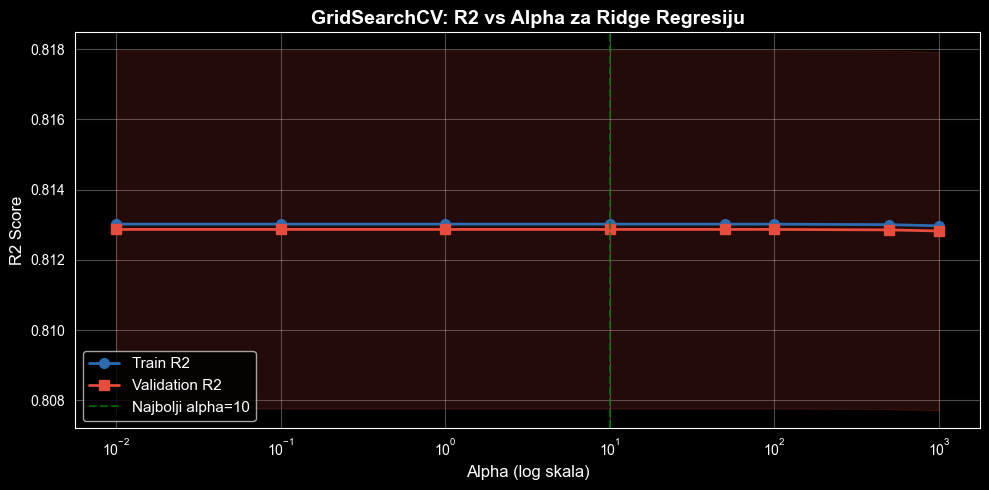

In [11]:
# Celija 6b: Vizualizacija CV rezultata

fig, ax = plt.subplots(figsize=(10, 5))

alphas = cv_results['param_alpha'].astype(float)
train_scores = cv_results['mean_train_score']
test_scores = cv_results['mean_test_score']
test_std = cv_results['std_test_score']

ax.plot(alphas, train_scores, 'o-', color='#2b6cb0', label='Train R2', linewidth=2, markersize=7)
ax.plot(alphas, test_scores, 's-', color='#e74c3c', label='Validation R2', linewidth=2, markersize=7)
ax.fill_between(alphas, test_scores - test_std, test_scores + test_std, alpha=0.15, color='#e74c3c')

ax.set_xscale('log')
ax.set_xlabel('Alpha (log skala)', fontsize=12)
ax.set_ylabel('R2 Score', fontsize=12)
ax.set_title('GridSearchCV: R2 vs Alpha za Ridge Regresiju', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Oznaci najbolji alpha
best_alpha = grid_search.best_params_['alpha']
best_score = grid_search.best_score_
ax.axvline(x=best_alpha, color='green', linestyle='--', alpha=0.7, label=f'Najbolji alpha={best_alpha}')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('ridge_alpha_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

### Analiza rezultata GridSearchCV

R2 score je praktično identičan (~0.813) za sve testirane alpha vrijednosti od 0.01 do 1000. Train i Validation linije se gotovo potpuno preklapaju, što ukazuje na sljedeće:

1. **Nema overfittinga** — razlika između train i validation R2 je zanemariva, što znači da Ridge regularizacija uspješno kontroliše kompleksnost modela.
2. **Model je stabilan bez obzira na alpha** — GridSearchCV je izabrao alpha=10 kao najbolji, ali razlika u odnosu na ostale vrijednosti je minimalna. Ovo znači da za ovaj dataset izbor alpha parametra nema značajan uticaj na performanse.
3. **Linearnost je glavno ograničenje** — model ne može preći ~0.82 R2 jer je Ridge linearna metoda. Dalje poboljšanje bi zahtijevalo nelinearne modele (npr. Random Forest, XGBoost) koji mogu uhvatiti složenije odnose između featura i cijene.

> Ovaj rezultat je očekivan za dataset sa 240,000 redova — dovoljno podataka da Ridge ne overfituje čak ni sa veoma malim alpha vrijednostima.

## Korak 7: Interpretacija Koeficijenata

Velika prednost Ridge regresije je **interpretabilnost**. Svaki koeficijent direktno govori koliko taj feature utice na cenu:
- **Pozitivan koeficijent** = povecava cenu
- **Negativan koeficijent** = smanjuje cenu

> **VAZNO:** Posto smo koristili `StandardScaler`, koeficijent npr. +5000 za `power_kw` znaci: kad `power_kw` poraste za **1 standardnu devijaciju** (ne za 1 kW!), cijena raste za ~5000 EUR.

### Šta je interpretabilnost?

Interpretabilnost znači koliko lako možemo objasniti **šta model radi i zašto daje određenu predikciju**. Ridge regresija je visoko interpretabilan model jer svaki feature ima jedan konkretan koeficijent koji direktno govori:
- **Koji feature** utiče na cenu
- **U kom smeru** — pozitivan koeficijent povećava cenu, negativan smanjuje
- **Koliko jako** — veći apsolutni koeficijent = jači uticaj

Na primjer, ako `power_kw` ima koeficijent +5000, to znači: kad snaga motora poraste za 1 standardnu devijaciju, cijena raste za ~5000 EUR.

> **Napomena:** Posto koristimo `StandardScaler`, koeficijenti se odnose na promenu od 1 standardne devijacije, a ne na promenu od 1 originalne jedinice (npr. 1 kW ili 1 km).

Nasuprot Ridge-u, modeli poput neuronskih mreža ili XGBoost-a mogu postići bolji R2, ali su tzv. "crna kutija" — daju predikciju bez jasnog objašnjenja zašto. Ridge je zato posebno koristan kada nam je bitno ne samo predvideti cenu, nego i **razumeti koji faktori na nju najviše utiču**.

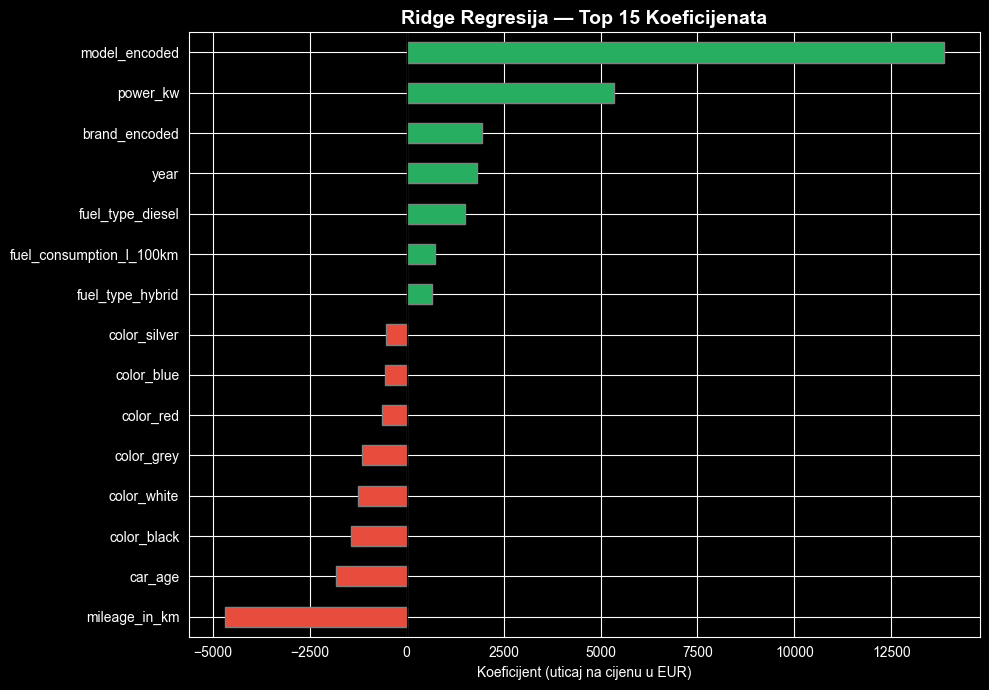

Top 5 koji POVECAVAJU cijenu:
model_encoded       13857.626147
power_kw             5355.975400
brand_encoded        1943.005631
year                 1811.169502
fuel_type_diesel     1514.495015
dtype: float64

Top 5 koji SMANJUJU cijenu:
mileage_in_km   -4686.190534
car_age         -1811.169502
color_black     -1430.574050
color_white     -1264.190619
color_grey      -1164.268647
dtype: float64


In [12]:
# Celija 7: Koeficijenti Ridge modela

coefs = pd.Series(best_ridge.coef_, index=X_train.columns)

# Top 15 po apsolutnoj vrijednosti
top15 = coefs.abs().sort_values(ascending=False).head(15)
top15_signed = coefs[top15.index].sort_values()

# Grafikon
plt.figure(figsize=(10, 7))
bar_colors = ['#e74c3c' if c < 0 else '#27ae60' for c in top15_signed]
top15_signed.plot(kind='barh', color=bar_colors, edgecolor='gray')
plt.title('Ridge Regresija — Top 15 Koeficijenata', fontsize=14, fontweight='bold')
plt.xlabel('Koeficijent (uticaj na cijenu u EUR)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('ridge_koeficijenti.png', dpi=150, bbox_inches='tight')
plt.show()

# Ispisi top 5 pozitivnih i negativnih
print("Top 5 koji POVECAVAJU cijenu:")
print(coefs.sort_values(ascending=False).head())
print("\nTop 5 koji SMANJUJU cijenu:")
print(coefs.sort_values().head())

### Interpretacija Top 15 Koeficijenata

Grafikon prikazuje 15 najuticajnijih featura na cenu automobila. Zeleni barovi povecavaju cenu, crveni je smanjuju.

**Najjaci pozitivni uticaji (povecavaju cenu):**
- **`model_encoded`** (~13,858 EUR) — daleko najdominantniji feature. Konkretan model automobila ima najveci uticaj na cenu, sto ima smisla — nije isto da li je u pitanju Golf ili Passat.
- **`power_kw`** (~5,356 EUR) — jaci motor = skuplje auto. Svaka standardna devijacija vise snage povecava cenu za ~5,356 EUR.
- **`brand_encoded`** (~1,943 EUR) — premium brendovi (BMW, Mercedes, Audi) podizu cenu.
- **`year`** (~1,811 EUR) — noviji automobili su skuplji.
- **`fuel_type_diesel`** (~1,514 EUR) — dizel vozila su u proseku skuplja od benzinskih.

**Najjaci negativni uticaji (smanjuju cenu):**
- **`mileage_in_km`** (~-4,900 EUR) — vise kilometara = niza cena. Ovo je drugi najjaci feature po apsolutnoj vrednosti.
- **`car_age`** (~-1,500 EUR) — starije auto = jeftinije. Logicno povezano sa `year`, ali model koristi oba jer nose razlicite informacije.
- **Boje** (`black`, `white`, `grey`, `red`, `blue`, `silver`) — sve imaju blago negativan uticaj. Ovo ne znaci da boja drasticno menja cenu, vec da su ove boje cesce kod jeftinijih modela u datasetu.

> **Napomena:** Koeficijenti se odnose na promenu od **1 standardne devijacije**, ne na promenu od 1 originalne jedinice. Npr. koeficijent za `power_kw` ne znaci +5,356 EUR po 1 kW, vec po ~jednu standardnu devijaciju snage (~68 kW u ovom datasetu).

## Korak 8: Finalna Evaluacija + Predicted vs Actual

Evaluiramo tunirani model na test setu i crtamo scatter plot. Ovo je kljucni grafikon koji vizuelno pokazuje kvalitet modela.

> **Citanje grafikona:** Sto su tacke blize crvenoj dijagonali (y = x liniji), model je bolji. Ocekujemo da Ridge lose predvidja skupe aute (tacke se razilaze desno). To je normalno — linearni model ne moze uhvatiti nelinearnosti u podacima.

In [13]:
# Celija 8: Finalna evaluacija Ridge

y_pred_ridge = best_ridge.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred_ridge)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2 = r2_score(y_test, y_pred_ridge)

print("=" * 40)
print("RIDGE REGRESSION (tuned)")
print("=" * 40)
print(f"Najbolji alpha: {grid_search.best_params_['alpha']}")
print(f"MAE:  {mae:,.2f} EUR")
print(f"RMSE: {rmse:,.2f} EUR")
print(f"R2:   {r2:.4f}")

# Poredjenje sa baseline
print("\n" + "=" * 40)
print("POREDJENJE: Baseline vs Tuned")
print("=" * 40)
print(f"{'Metrika':<10} {'Baseline':>12} {'Tuned':>12} {'Razlika':>12}")
print("-" * 48)
print(f"{'MAE':<10} {mae_b:>12,.2f} {mae:>12,.2f} {mae_b - mae:>+12,.2f}")
print(f"{'RMSE':<10} {rmse_b:>12,.2f} {rmse:>12,.2f} {rmse_b - rmse:>+12,.2f}")
print(f"{'R2':<10} {r2_b:>12.4f} {r2:>12.4f} {r2 - r2_b:>+12.4f}")

RIDGE REGRESSION (tuned)
Najbolji alpha: 10
MAE:  5,861.95 EUR
RMSE: 10,694.83 EUR
R2:   0.8215

POREDJENJE: Baseline vs Tuned
Metrika        Baseline        Tuned      Razlika
------------------------------------------------
MAE            5,862.07     5,861.95        +0.13
RMSE          10,694.82    10,694.83        -0.00
R2               0.8215       0.8215      -0.0000


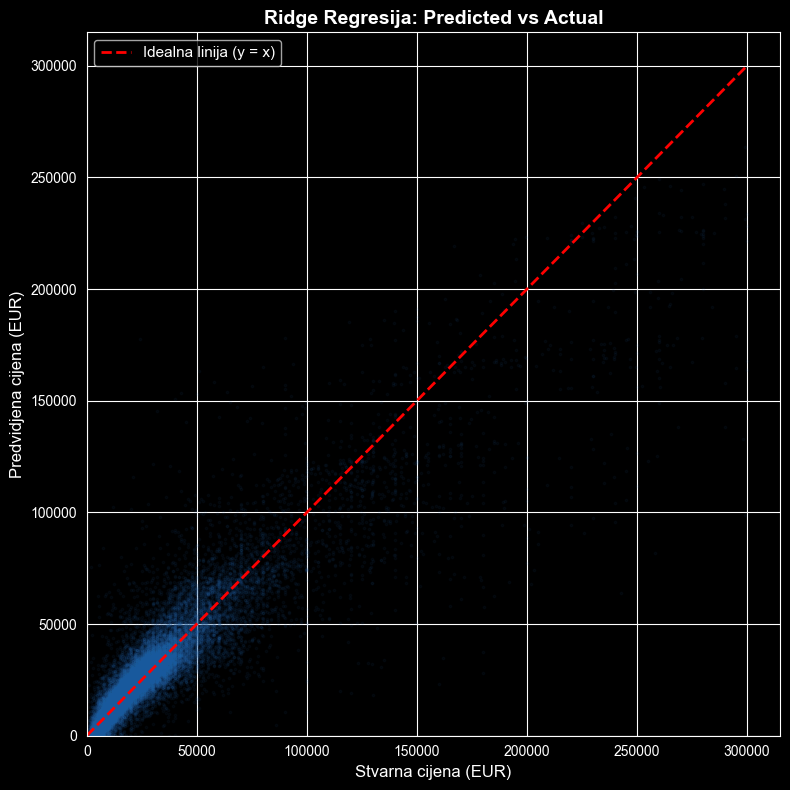

In [14]:
# Celija 8b: Predicted vs Actual scatter plot

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(y_test, y_pred_ridge, alpha=0.05, s=3, color='#2b6cb0')

max_val = max(y_test.max(), y_pred_ridge.max())
ax.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Idealna linija (y = x)')

ax.set_xlabel('Stvarna cijena (EUR)', fontsize=12)
ax.set_ylabel('Predvidjena cijena (EUR)', fontsize=12)
ax.set_title('Ridge Regresija: Predicted vs Actual', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, max_val * 1.05)
ax.set_ylim(0, max_val * 1.05)

plt.tight_layout()
plt.savefig('ridge_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

### Analiza: Predicted vs Actual

Scatter plot prikazuje odnos izmedju stvarne cene (x-osa) i predvidjene cene (y-osa). Crvena isprekidana linija predstavlja idealnu predikciju (y = x) — kad bi model bio savrsen, sve tacke bi lezale tacno na toj liniji.

**Sta vidimo:**
- **Za automobile do ~50,000 EUR** — model radi solidno. Tacke su gusto koncentrisane oko idealne linije, sto znaci da su predikcije za vecinu automobila prilicno tacne.
- **Za automobile iznad ~50,000 EUR** — tacke se sve vise razilaze od idealne linije. Model ima tendenciju da **potcenjuje cenu skupih automobila** (tacke padaju ispod crvene linije).
- **Najveca gustina podataka** je u donjem levom uglu (0–50,000 EUR), sto odgovara distribuciji cena u datasetu — vecina automobila je u tom opsegu.

**Zasto model lose predvidja skupe automobile?**
Ridge je linearni model i pretpostavlja linearan odnos izmedju featura i cene. Kod skupih automobila (luksuzni brendovi, retki modeli) postoje nelinearni faktori koji uticu na cenu (ekskluzivnost, retka oprema, kolekcionar vrednost) koje linearni model ne moze uhvatiti.

> Ovo je ocekivano ponasanje za Ridge regresiju i predstavlja jedno od glavnih ogranicenja linearnih modela. Nelinearni modeli (Random Forest, XGBoost) bi trebalo da bolje predvidjaju cene u visokom opsegu.

### Distribucija Residuala (gresaka)

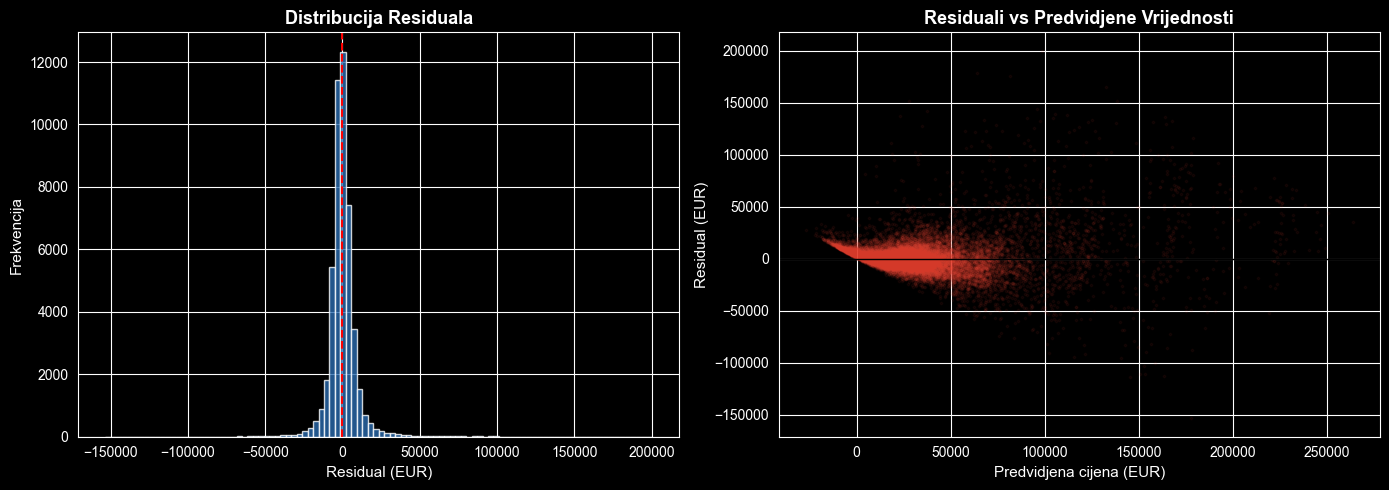

Srednji residual: 87.24 EUR
Std residuala:    10,694.58 EUR


In [15]:
# Celija 8c: Distribucija residuala

residuals = y_test - y_pred_ridge

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram residuala
axes[0].hist(residuals, bins=100, color='#2b6cb0', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('Residual (EUR)', fontsize=11)
axes[0].set_ylabel('Frekvencija', fontsize=11)
axes[0].set_title('Distribucija Residuala', fontsize=13, fontweight='bold')

# Residuals vs Predicted
axes[1].scatter(y_pred_ridge, residuals, alpha=0.05, s=3, color='#e74c3c')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Predvidjena cijena (EUR)', fontsize=11)
axes[1].set_ylabel('Residual (EUR)', fontsize=11)
axes[1].set_title('Residuali vs Predvidjene Vrijednosti', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('ridge_residuali.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Srednji residual: {residuals.mean():,.2f} EUR")
print(f"Std residuala:    {residuals.std():,.2f} EUR")

### Analiza Residuala (gresaka modela)

Residual = stvarna cena - predvidjena cena. Ako je residual 0, model je tacno pogodio. Pozitivan residual znaci da je model potcenio cenu, negativan da je precenio.

**Levi grafikon — Distribucija Residuala:**
- Distribucija je priblizno normalna i centrirana oko 0 (srednji residual = 87.24 EUR), sto je dobar znak — model nema sistematsku pristrasnost (bias).
- Standardna devijacija residuala je ~10,695 EUR, sto odgovara RMSE vrednosti.
- Distribucija je blago asimetricna sa "repom" ka negativnim vrednostima (do -150,000 EUR), sto znaci da model ponekad znacajno preceni cenu nekim skupim automobilima.

**Desni grafikon — Residuali vs Predvidjene Vrednosti:**
- Za predikcije do ~25,000 EUR residuali su gusto koncentrisani oko nule — model radi dobro u ovom opsegu.
- Sa rastom predvidjene cene, residuali se sve vise sire (oblik "levka"). Ovo se zove **heteroskedasticnost** — varijansa greske raste sa cenom.
- Ovo znaci da model pravi vece greske kod skupljih automobila, sto je konzistentno sa Predicted vs Actual grafikonom.

> **Heteroskedasticnost** je tipicna za podatke o cenama i jedno od ogranicenja linearnih modela. Moguce resenje je log-transformacija target varijable (`log(price)`), ali to menja interpretaciju koeficijenata.

## Korak 9: Sacuvaj Ridge Model i Rezultate

In [16]:
# Celija 9: Cuvanje modela i rezultata

# Kreiraj models/ folder ako ne postoji
os.makedirs('../models', exist_ok=True)

# Sacuvaj model i scaler
joblib.dump(best_ridge, '../models/ridge_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

# Sacuvaj rezultate u dict (za finalnu tabelu poredjenja modela)
ridge_results = {
    'Model': 'Ridge Regression',
    'Najbolji alpha': grid_search.best_params_['alpha'],
    'MAE (EUR)': round(mae, 2),
    'RMSE (EUR)': round(rmse, 2),
    'R2': round(r2, 4)
}

print("Model i scaler sacuvani u ../models/")
print("\nFinalni rezultati:")
for k, v in ridge_results.items():
    print(f"  {k}: {v}")

Model i scaler sacuvani u ../models/

Finalni rezultati:
  Model: Ridge Regression
  Najbolji alpha: 10
  MAE (EUR): 5861.95
  RMSE (EUR): 10694.83
  R2: 0.8215


---

## Rezime

| Stavka | Vrijednost |
|--------|-----------|
| **Model** | Ridge Regression (L2 regularizacija) |
| **Encoding** | Target Encoding (brand, model) + One-Hot Encoding (transmission, fuel, color) |
| **Skaliranje** | StandardScaler (fit na train, transform na oba) |
| **Tuning** | GridSearchCV, 5-fold CV, 8 alpha vrijednosti |
| **Evaluacija** | MAE, RMSE, R2 na test setu |

Sacuvani fajlovi:
- `ridge_model.pkl` — trenirani Ridge model
- `scaler.pkl` — StandardScaler (potreban za nove podatke)
- `ridge_koeficijenti.png` — vizualizacija koeficijenata
- `ridge_pred_vs_actual.png` — predicted vs actual scatter
- `ridge_alpha_tuning.png` — CV rezultati po alpha vrijednostima
- `ridge_residuali.png` — distribucija gresaka modela